In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('earthquake_1995-2023.csv')

print(df.head()) # Initial inspection of the data
print(df.columns)

                                      title  magnitude         date_time  cdi  \
0          M 6.5 - 42 km W of Sola, Vanuatu        6.5  16-08-2023 12:47    7   
1  M 6.5 - 43 km S of Intipucá, El Salvador        6.5  19-07-2023 00:22    8   
2  M 6.6 - 25 km ESE of Loncopué, Argentina        6.6  17-07-2023 03:05    7   
3     M 7.2 - 98 km S of Sand Point, Alaska        7.2  16-07-2023 06:48    6   
4                  M 7.3 - Alaska Peninsula        7.3  16-07-2023 06:48    0   

   mmi   alert  tsunami  sig net  nst      dmin    gap magType    depth  \
0    4   green        0  657  us  114  7.177000   25.0     mww  192.955   
1    6  yellow        0  775  us   92  0.679000   40.0     mww   69.727   
2    5   green        0  899  us   70  1.634000   28.0     mww  171.371   
3    6   green        1  860  us  173  0.907000   36.0     mww   32.571   
4    5     NaN        1  820  at   79  0.879451  172.8      Mi   21.000   

   latitude  longitude               location      continent  

In [3]:
print(df.info)
print(df.dtypes) # Want to know more of what the data looks like

<bound method DataFrame.info of                                          title  magnitude         date_time  \
0             M 6.5 - 42 km W of Sola, Vanuatu        6.5  16-08-2023 12:47   
1     M 6.5 - 43 km S of Intipucá, El Salvador        6.5  19-07-2023 00:22   
2     M 6.6 - 25 km ESE of Loncopué, Argentina        6.6  17-07-2023 03:05   
3        M 7.2 - 98 km S of Sand Point, Alaska        7.2  16-07-2023 06:48   
4                     M 7.3 - Alaska Peninsula        7.3  16-07-2023 06:48   
..                                         ...        ...               ...   
995          M 7.1 - 85 km S of Tungor, Russia        7.1  27-05-1995 13:03   
996     M 7.7 - 249 km E of Vao, New Caledonia        7.7  16-05-1995 20:12   
997  M 6.9 - 27 km NNW of Maubara, Timor Leste        6.9  14-05-1995 11:33   
998           M 6.6 - 10 km W of Aianí, Greece        6.6  13-05-1995 08:47   
999  M 7.1 - 14 km NE of Cabatuan, Philippines        7.1  05-05-1995 03:53   

     cdi  mmi   ale

In [4]:
print(df.describe)

<bound method NDFrame.describe of                                          title  magnitude         date_time  \
0             M 6.5 - 42 km W of Sola, Vanuatu        6.5  16-08-2023 12:47   
1     M 6.5 - 43 km S of Intipucá, El Salvador        6.5  19-07-2023 00:22   
2     M 6.6 - 25 km ESE of Loncopué, Argentina        6.6  17-07-2023 03:05   
3        M 7.2 - 98 km S of Sand Point, Alaska        7.2  16-07-2023 06:48   
4                     M 7.3 - Alaska Peninsula        7.3  16-07-2023 06:48   
..                                         ...        ...               ...   
995          M 7.1 - 85 km S of Tungor, Russia        7.1  27-05-1995 13:03   
996     M 7.7 - 249 km E of Vao, New Caledonia        7.7  16-05-1995 20:12   
997  M 6.9 - 27 km NNW of Maubara, Timor Leste        6.9  14-05-1995 11:33   
998           M 6.6 - 10 km W of Aianí, Greece        6.6  13-05-1995 08:47   
999  M 7.1 - 14 km NE of Cabatuan, Philippines        7.1  05-05-1995 03:53   

     cdi  mmi   a

In [5]:
# I want to convert the pre-existing date_time column with pd.date_time so I can actually pull tangible metrics with time and dates cooporating 

df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')

# Now I will make a year column that corresponds to the years

df['year'] = df['date_time'].dt.year

print(df['year'].unique()) # Mind this line, I just wanted to know how many years of data are present in the data

top_5_quake_years = (
    df.groupby('year')
    .size()
    .sort_values(ascending=False)
    .head(5)
)

print(top_5_quake_years) # Checking the output

[2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011 2010
 2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 1999 1998 1997 1996
 1995]
year
2013    53
2015    53
2014    48
2018    43
2016    43
dtype: int64


In [6]:
mag_per_country = df.groupby('country')['magnitude'].mean()

print(mag_per_country)

country
Afghanistan                                                   6.730000
Algeria                                                       6.800000
Antarctica                                                    6.866667
Argentina                                                     6.766667
Azerbaijan                                                    6.650000
Bolivia                                                       6.675000
Botswana                                                      6.500000
Brazil                                                        6.666667
Canada                                                        7.800000
Chile                                                         6.921429
Colombia                                                      6.837500
Costa Rica                                                    6.866667
Ecuador                                                       7.030000
El Salvador                                                   6.55000

In [7]:
unique_per_country = df.groupby('country')['magnitude'].nunique()

print(unique_per_country)

# Now will sort for the top 10

quake_counts = unique_per_country.sort_values(ascending=False) # filters the values in a descending fashion

top_10_quakes = quake_counts.head(10)
print(top_10_quakes)

country
Afghanistan                                                    4
Algeria                                                        1
Antarctica                                                     3
Argentina                                                      5
Azerbaijan                                                     2
Bolivia                                                        3
Botswana                                                       1
Brazil                                                         3
Canada                                                         1
Chile                                                         14
Colombia                                                       6
Costa Rica                                                     2
Ecuador                                                        9
El Salvador                                                    2
Fiji                                                           8
Greece           

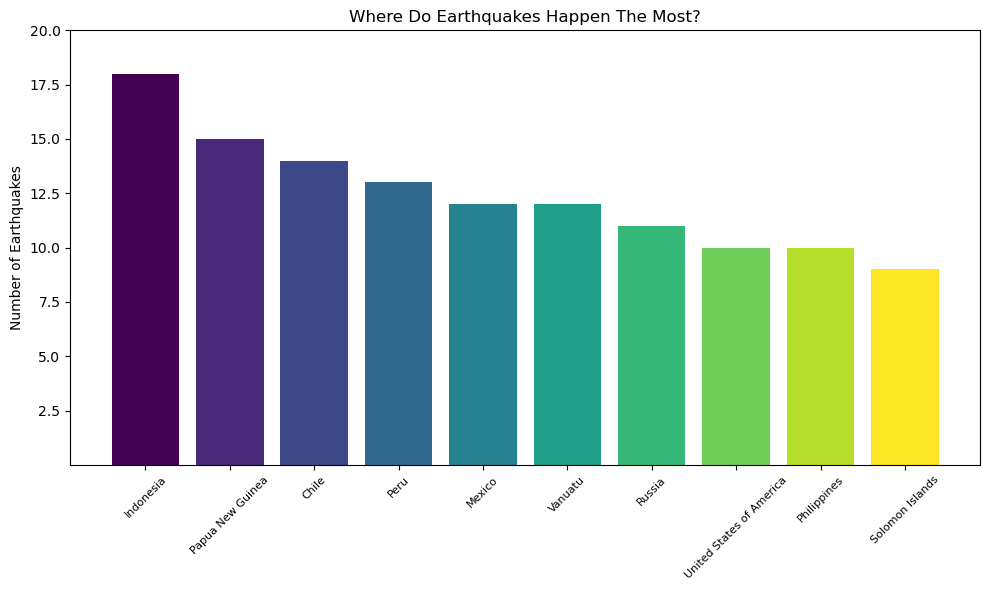

<Figure size 640x480 with 0 Axes>

In [8]:
colors = plt.cm.viridis(np.linspace(0, 1, len(top_10_quakes))) # creating an array of colors for data distinctions

plt.figure(figsize=(10,6))

plt.bar(top_10_quakes.keys(), top_10_quakes.values, color=colors)

plt.title("Where Do Earthquakes Happen The Most?")
plt.xticks(size=8, rotation=45)
plt.ylabel("Number of Earthquakes")
plt.yticks([2.5,5.0,7.5,10.0,12.5,15.0,17.5,20.0])

plt.tight_layout()
plt.show()
plt.clf()

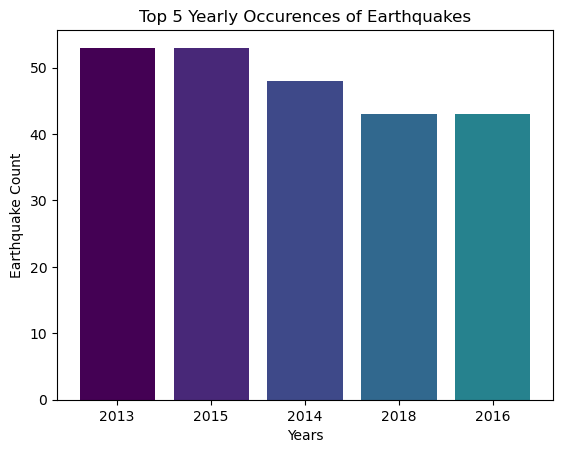

<Figure size 640x480 with 0 Axes>

In [9]:
x_pos = range(len(top_5_quake_years)) # This line has to be here because matplotlib was giving me troubles only refrencing top_5_quake_years.index

plt.figure()
plt.bar(x_pos, top_5_quake_years.values, color=colors)
plt.title("Top 5 Yearly Occurences of Earthquakes")

plt.xticks(x_pos, top_5_quake_years.index)
plt.xlabel("Years")
plt.ylabel("Earthquake Count")

plt.show()
plt.clf()

In [10]:
# Knowing where the top 5 'magnitude' Earthquakes is a good statistic

top_5_mag_loc = df.sort_values(by='magnitude', ascending=False).head(5)
print(top_5_mag_loc) # Very lengthy output, have to narrow it down

print(top_5_mag_loc[['magnitude', 'location']])

                                                 title  magnitude  \
703  M 9.1 - 2004 Sumatra - Andaman Islands Earthquake        9.1   
511        M 9.1 - 2011 Great Tohoku Earthquake, Japan        9.1   
552               M 8.8 - 36 km WNW of Quirihue, Chile        8.8   
476     M 8.6 - off the west coast of northern Sumatra        8.6   
692            M 8.6 - 78 km WSW of Singkil, Indonesia        8.6   

              date_time  cdi  mmi   alert  tsunami   sig       net  nst  dmin  \
703 2004-12-26 00:58:00    0    8     NaN        0  1274  official  601   0.0   
511 2011-03-11 05:46:00    9    8     NaN        0  2184  official  541   0.0   
552 2010-02-27 06:34:00    8    8     NaN        0  1991  official  454   0.0   
476 2012-04-11 08:38:00    9    7  yellow        0  2048  official  499   0.0   
692 2005-03-28 16:09:00    0    8     NaN        0  1138  official  510   0.0   

      gap magType  depth  latitude  longitude  \
703  22.0      mw   30.0     3.295     95.982   


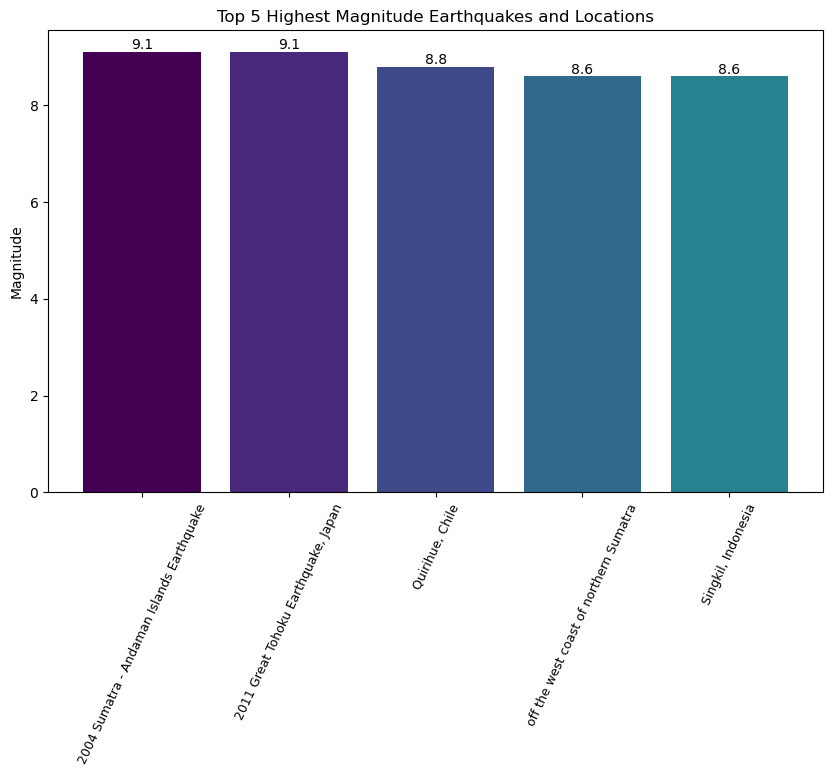

<Figure size 640x480 with 0 Axes>

In [11]:
plt.figure(figsize=(10,6))

bars = plt.bar(top_5_mag_loc['location'],top_5_mag_loc['magnitude'], color=colors)

# The loop below is only for creating numbers ontop of our bars in our barchart
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )
        

plt.title("Top 5 Highest Magnitude Earthquakes and Locations")
plt.xticks(size=9, rotation=65)
plt.ylabel("Magnitude")


plt.show()
plt.clf()

In [12]:
# Now for this last graph, Being able to see a plot of countries with the highest average magnitudes (That aren't just one off earthquake occurences) can help us visualize patterns.

                                                    count      mean
country                                                            
Turkiye                                                 3  7.333333
Pakistan                                                5  7.280000
United Kingdom of Great Britain and Northern Ir...      5  7.220000
Peru                                                   26  7.200000
Venezuela                                               2  7.150000
Fiji                                                   10  7.100000
Nepal                                                   4  7.100000
Haiti                                                   2  7.100000
Ecuador                                                10  7.030000
Mexico                                                 31  7.016129


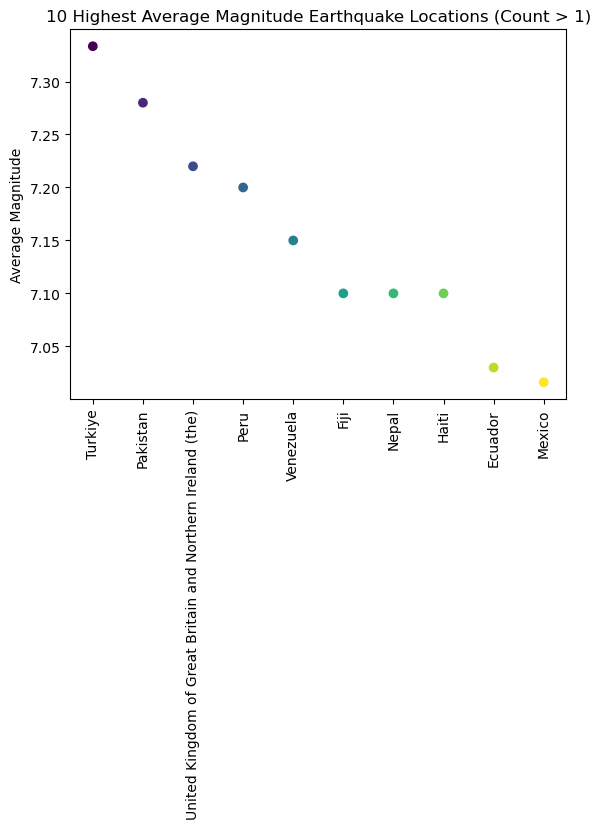

<Figure size 640x480 with 0 Axes>

In [13]:
country_stats = (df.groupby('country')['magnitude'].agg(['count', 'mean']))

filtered_stats = country_stats[country_stats['count'] > 1]

top_10_mean_stats = (filtered_stats.sort_values(by='mean', ascending=False).head(10))
print(top_10_mean_stats)
                                                         
plt.figure()

x_pos = range(len(top_10_mean_stats)) # to make sure the plot accurately appears, added this line precationarily, mentioned the reasons earlier in a comment
colors = plt.cm.viridis(np.linspace(0, 1, len(top_10_mean_stats)))

plt.scatter(x_pos, top_10_mean_stats['mean'], color=colors)

plt.xticks(x_pos, top_10_mean_stats.index, rotation=90)

plt.ylabel('Average Magnitude')
plt.title('10 Highest Average Magnitude Earthquake Locations (Count > 1)') 

plt.show()
plt.clf()